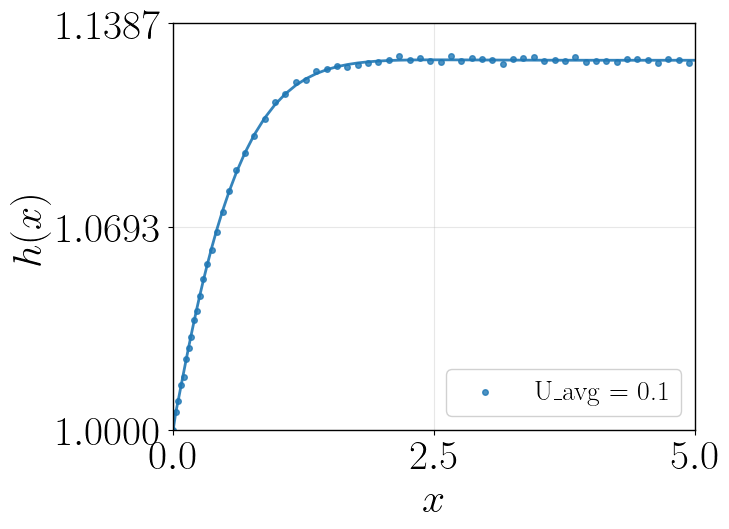

c:\Users\paraj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 25 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
c:\Users\paraj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 18 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
c:\Users\paraj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calli

Trained pressure GPR: 210 samples x 5 pressure points (input dim 3).


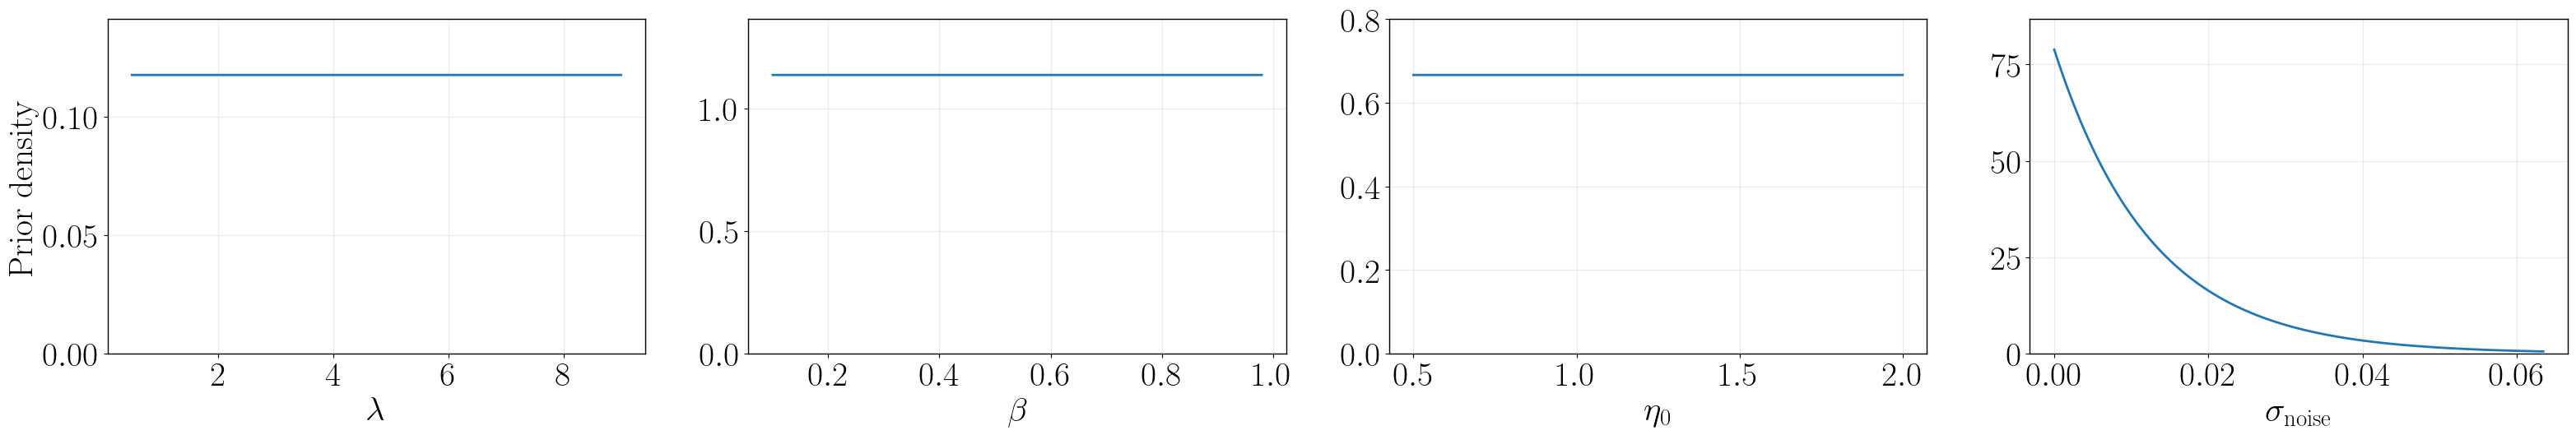

100%|██████████| 10000/10000 [00:44<00:00, 226.03it/s]


N1 (oldroyd) = 0.118756  at shear rate 0.4

Parameter              Mean          Std     Rhat     95% CI low    95% CI high
lambda           6.4850e-01   7.9555e-02   1.0151     5.0962e-01     8.1994e-01
beta             4.1981e-01   7.9355e-02   1.0110     2.4916e-01     5.6768e-01
eta_0            9.8634e-01   1.1691e-03   1.0040     9.8402e-01     9.8827e-01
sigma_noise      1.0985e-03   8.3734e-04   1.0040     4.0925e-04     3.1266e-03

Posterior predictive (U=0.1, 95% band)
  coverage=100.0%  rms_z=0.54  max|z|=1.31  mean_z=-0.37


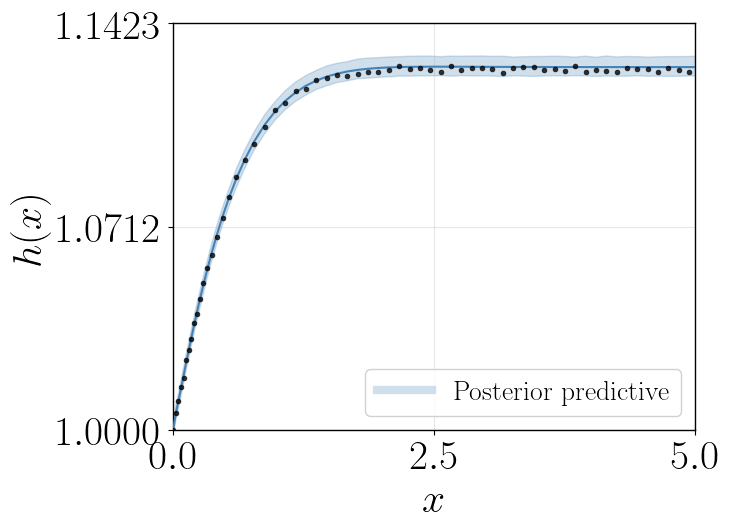


Pressure posterior predictive (95% band)
  coverage=100.0%  rms_z=0.31  max|z|=0.58  mean_z=-0.01


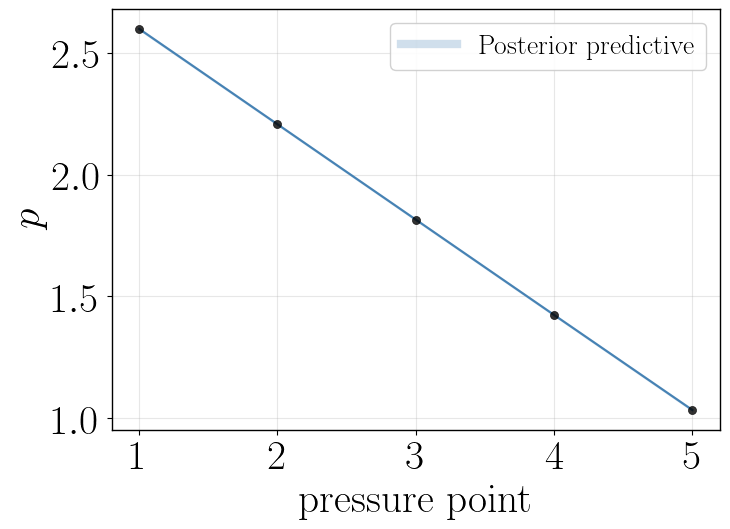

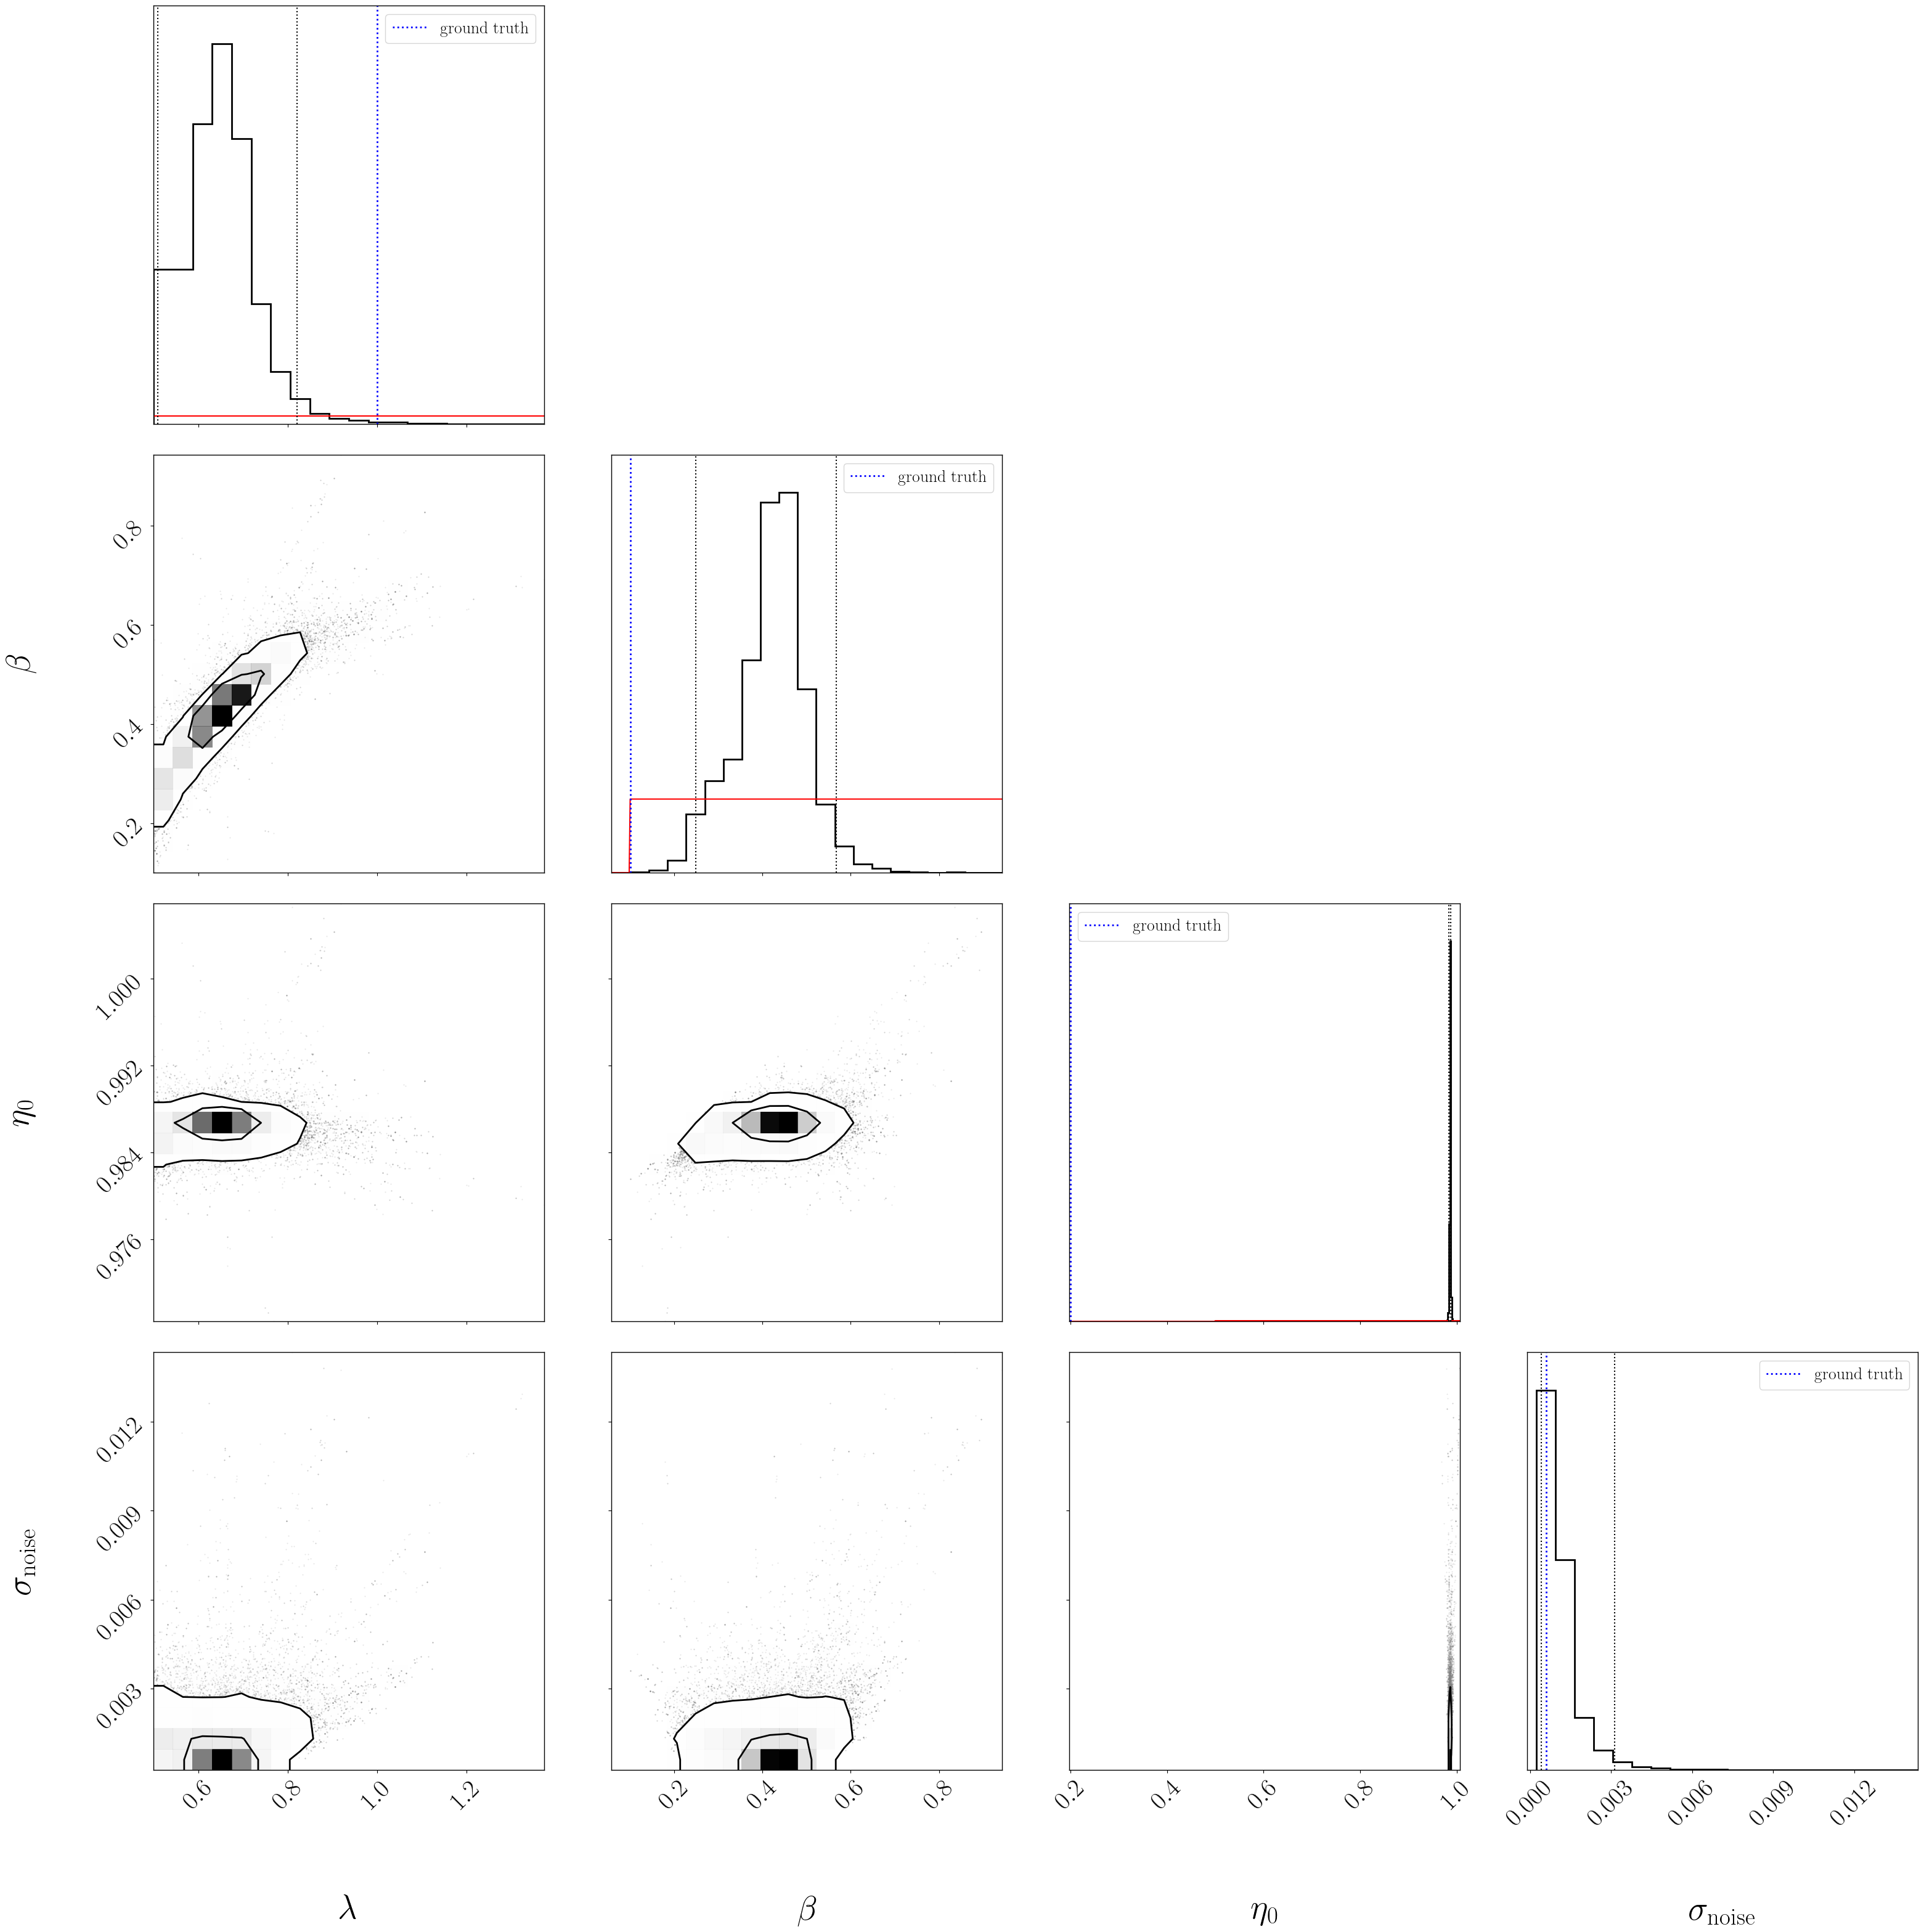

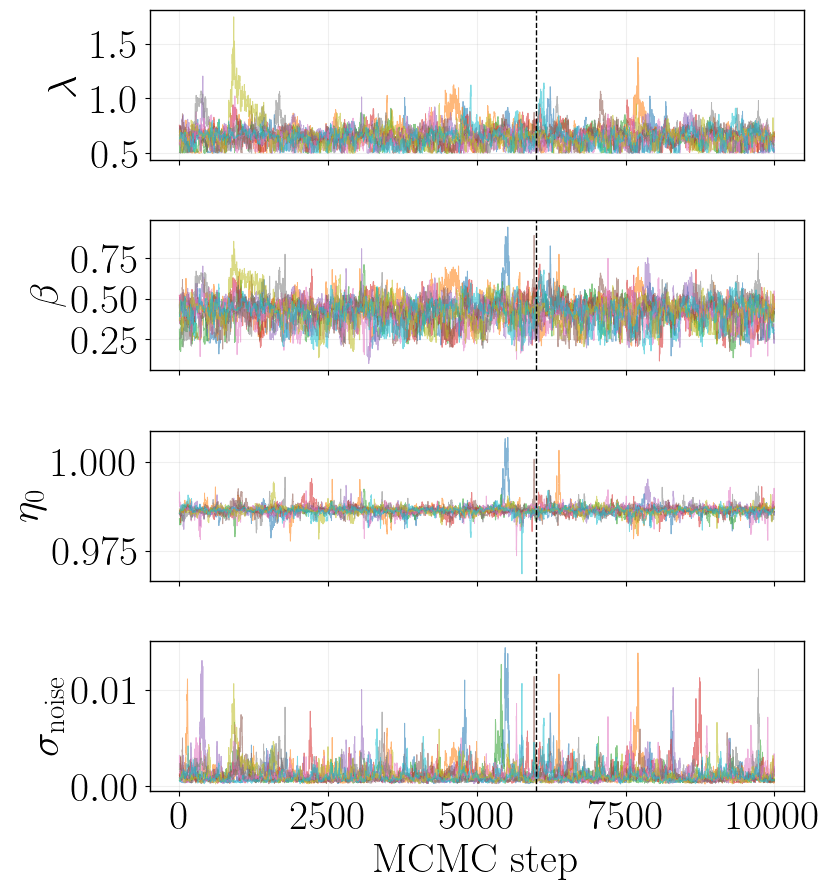

In [10]:
import sys
import os
from pathlib import Path

CURRENT_DIR = os.getcwd()
FAXEN_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..'))
sys.path.append(FAXEN_ROOT)
from packages import ROMCurve4BayesianInference

model = ROMCurve4BayesianInference(
    swell_root=Path(FAXEN_ROOT),
    model="oldroyd",  # "oldroyd", " ", or "ptt"
    train_data_rels=["datas/oldroyd-rom3/curve4_y_all.txt"],
    mode="swell_height",  # or "full_curve"
    rom_method="rbf",
    scaler="minmax",
    eps=1e-6,
    sigma_noise_percent=0.5,
    lambda_bounds = (0.5, 9.0),
    beta_bounds = (0.1, 0.98),
    eta0_bounds = (0.5, 2.0),
    thin=2,
    sigma_bias=None,
    use_pressure = True,
    augment_eta0=True,
    pressure_filename= "pressure_all.txt",
    true_theta=[1.0, 0.1, 0.2])

model.load_data(filename="datas/oldroyd-rom3/giesekus2/curve4_y.txt", 
                u_avg_obs=0.1, pressure_filename="datas/oldroyd-rom3/giesekus2/pressure.txt")

model.plot_data()  
model.build_rom()
model.plot_prior()
model.run_mcmc(nwalkers=10, nsteps=10000)
model.compute_N1()
model.print_diagnostics()
model.plot_posterior_predictive()
model.plot_corner_all()
model.plot_trace_all()